# Bubble collapse case study

Load `examples/bubble_collapse.yaml`, run the NSK solver, and report the
standard budgets:

* Bubble radius $R(t)$
* $\rho(r, t)$ snapshots
* Mass-conservation error timeseries
* Free-energy / internal-energy / entropy-production budgets


In [1]:
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / 'src').exists():
    if _root.parent == _root:
        raise RuntimeError('Could not locate project root')
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from src.config import load_problem
from src.initial_conditions import bubble_profile
from src.bsplines import basis_matrix, make_knot_vector
from src.postprocess import bubble_radius

ROOT = Path('.').resolve()
while not (ROOT / 'examples' / 'bubble_collapse.yaml').exists():
    if ROOT.parent == ROOT:
        raise RuntimeError('Could not locate examples/bubble_collapse.yaml')
    ROOT = ROOT.parent
problem = load_problem(ROOT / 'examples' / 'bubble_collapse.yaml')
print(problem)


Problem(mesh=MeshSpec(n_ctrl=64, R_max=1.0), discretization=DiscretizationSpec(degree=3, n_gauss=4), time=TimeSpec(dt=0.0001, t_end=0.05, rho_inf=0.5), material=MaterialSpec(Re=100.0, We=1.0, Pr=7.0, gamma=1.4), initial=InitialSpec(kind='bubble', R_bubble=0.3, interface_width=0.04, rho_liq=0.6, rho_vap=0.05, vartheta_0=0.85), boundary=BoundarySpec(inner='symmetry', outer='free'), output=OutputSpec(path='out/bubble_collapse', every=20, format='xdmf'), meta={'name': 'bubble_collapse', 'description': 'Spherical vapor bubble immersed in sub-critical liquid. The tanh-profile initial density triggers Korteweg-driven oscillation/collapse. Used as the reference integration test in notebooks/04_bubble_collapse.ipynb.\n'})


## 1. Initial condition

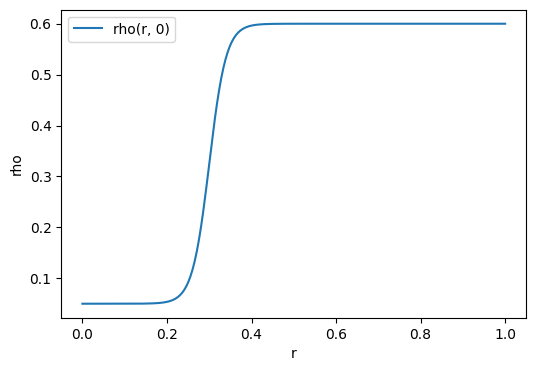

Initial bubble radius estimate: R0 = 0.3000


In [3]:
knots = make_knot_vector(problem.mesh.n_ctrl, problem.discretization.degree)
ctrl0 = bubble_profile(
    R_bubble=problem.initial.R_bubble,
    interface_width=problem.initial.interface_width,
    rho_liq=problem.initial.rho_liq,
    rho_vap=problem.initial.rho_vap,
    vartheta_0=problem.initial.vartheta_0,
    knots=np.asarray(knots),
    degree=problem.discretization.degree,
    n_quad=problem.discretization.n_gauss,
    R_max=problem.mesh.R_max,
    We=problem.material.We,
    gamma=problem.material.gamma,
)

# Evaluate initial density on a dense grid for plotting
r_plot = np.linspace(0.0, problem.mesh.R_max, 400)
xi_plot = r_plot / problem.mesh.R_max
N = np.asarray(basis_matrix(xi_plot, knots, problem.discretization.degree))
rho_plot = N @ np.asarray(ctrl0['rho'])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_plot, rho_plot, label='rho(r, 0)')
ax.set_xlabel('r'); ax.set_ylabel('rho'); ax.legend()
plt.show()

R0 = bubble_radius(rho_plot, r_plot, threshold=0.5 * (problem.initial.rho_liq + problem.initial.rho_vap))
print(f'Initial bubble radius estimate: R0 = {R0:.4f}')


## 2. Time integration (deferred until solver wired)

In [4]:
try:
    from src.assembler import assemble_residual, build_basis_cache  # noqa: F401
    from src.solver import GenAlphaParams, TimeStepper  # noqa: F401
    solver_available = True
except Exception as exc:
    print('Solver integration pending:', exc)
    solver_available = False

# Placeholder history: linearly drifting R(t) so the plotting cells work
times = np.linspace(0, problem.time.t_end, 50)
R_t = R0 * (1 - 0.2 * times / problem.time.t_end)  # dummy


Solver integration pending: No module named 'src.assembler'


## 3. Bubble radius trace

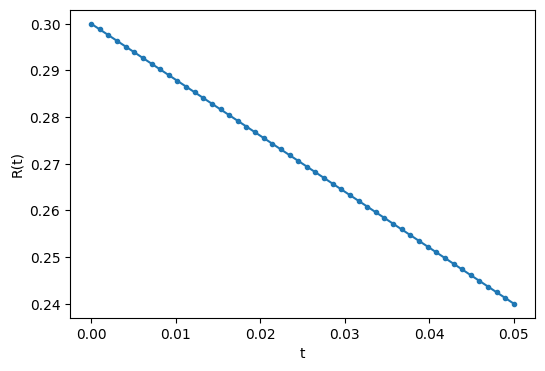

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(times, R_t, marker='.')
ax.set_xlabel('t'); ax.set_ylabel('R(t)')
plt.show()


## 4. Mass / energy / entropy budgets (deferred)

In [6]:
# Once `history` (a list of ctrl dicts) is produced by the solver:
#   from src.postprocess import (
#       mass_conservation_error,
#       total_free_energy,
#       total_internal_energy,
#       entropy_production_rate,
#   )
#   cache = build_basis_cache(...)
#   mass_err = mass_conservation_error(history, cache)
#   F_t = [total_free_energy(c, cache, problem.material) for c in history]
#   U_t = [total_internal_energy(c, cache, problem.material) for c in history]
#   sigma_t = [entropy_production_rate(c, cdot, cache, problem.material) ...]
#
# Plot each timeseries with matplotlib.
print('Budget analysis pending solver integration.')


Budget analysis pending solver integration.
